In [1]:
%load_ext autoreload
%autoreload 2
import sys
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from os.path import join
import os
import seaborn as sns

config_dir = "../../config"
if config_dir not in sys.path:
    sys.path.insert(0, config_dir)

from config import add_to_path, root_dir, google_folder_id, download_dir
add_to_path(join(root_dir, 'src'))
import utils.visualization as visualisation
import utils.preprocessing as preprocessing
from data_loader import load_data

Added to sys: d:\GMM 4\Reading seminar\Reading-Seminar-anomaly-detection\src


# Goal

The goal of the analysis is to use [dynamic PCA](https://doi.org/10.1016/j.ress.2025.111441) proposed by Yin et al. to detect the anomalies of each session. The temporal correlation is also considered in this method via a lag-augmented matrix. 

Steps : 
- Construct a PCA / DPCA space
    - Using other analysis to have a list of clean session
    - Preprocessing
    - Use the [Local Outlier Factor](https://en.wikipedia.org/wiki/Local_outlier_factor) to detect the outlier of the clean session, then replace them using moving average
    - For DPCA : construct a lag-augmented matrix
    - Do PCA on the full dataset
- Estimate the SPE threshold : chi2 distribution
- Analyze the test data

# PCA Space construction

In [5]:
data_dict, extracted_dir = load_data(
    file_id=google_folder_id,
    work_dir=join(download_dir, "gdrive_tar_data"),
    tar_name="data.tar",
    pattern="*.csv",
)

list_keys = list(data_dict.keys())

In [6]:
list_session = []
for s in list_keys:
    df = data_dict[s].copy()
    if preprocessing.clean_dataframe(df).shape[0] != 0:
        list_session.append(s)

In [7]:
len(list_session)

40

In [8]:
# Using the result of anl02p1, PCA

session_anomaly = ['T24S12-04_E-AL2706',
 'T24S12-04_E-AL2725',
 'T24S12-04_E-AL2761',
 'T24S12-04_E-AL2780',
 'T24S12-04_E-AL2819',
 'T24S12-04_E-AL2948',
 'T24S12-04_E-AL3089',
 'T24S12-04_E-AL3155',
 'T24S12-04_E-AL3597',
 'T24S12-04_E-AL3674']

In [9]:
session_clean = [
    k for k in list_session
    if os.path.splitext(os.path.basename(k))[0] not in session_anomaly
]
len(session_clean)

30

In [10]:
session_clean_names = [
    os.path.splitext(os.path.basename(k))[0]
    for k in session_clean
]

## Example of LOF

In [11]:
df = data_dict[session_clean[2]].copy()
df = preprocessing.clean_dataframe(df)

In [12]:
data_dict[session_clean[2]].head()

,datetime,nwl1,nwl2,nwl3,nwl4,fprd1,fprd2,fprd3,fprd4,pstr1,pstr3,astrw,g2,ny,vcrf,v2
0,2024-05-01T20:38:19.102,1906.82,2030.15,2005.83,1982.56,2683.77,3009.00,8826.10,9766.66,4.46974,2.31353,1.14311,-0.263083,-1.59533,247.638,-3.121770
1,2024-05-01T20:38:19.112,1914.42,2026.60,2005.83,1978.41,4046.93,3335.88,8250.99,9176.26,4.06397,2.35686,1.25627,-0.096768,-1.59533,247.638,-2.744750
2,2024-05-01T20:38:19.122,1909.67,2031.33,2008.01,1978.41,3368.82,2406.25,8047.23,7627.03,3.99114,2.85514,1.12695,-0.084888,-1.30076,247.726,0.208565
3,2024-05-01T20:38:19.132,1909.67,2031.33,2008.01,1985.68,3250.59,2722.69,7960.14,8167.09,4.39691,2.54101,1.38558,-0.179925,-1.36874,247.726,-0.639728
4,2024-05-01T20:38:19.142,1915.37,2031.33,2010.20,1984.64,5160.86,3647.68,7238.78,8425.67,3.89750,2.77932,1.16736,-0.073008,-1.22145,247.815,-2.273480


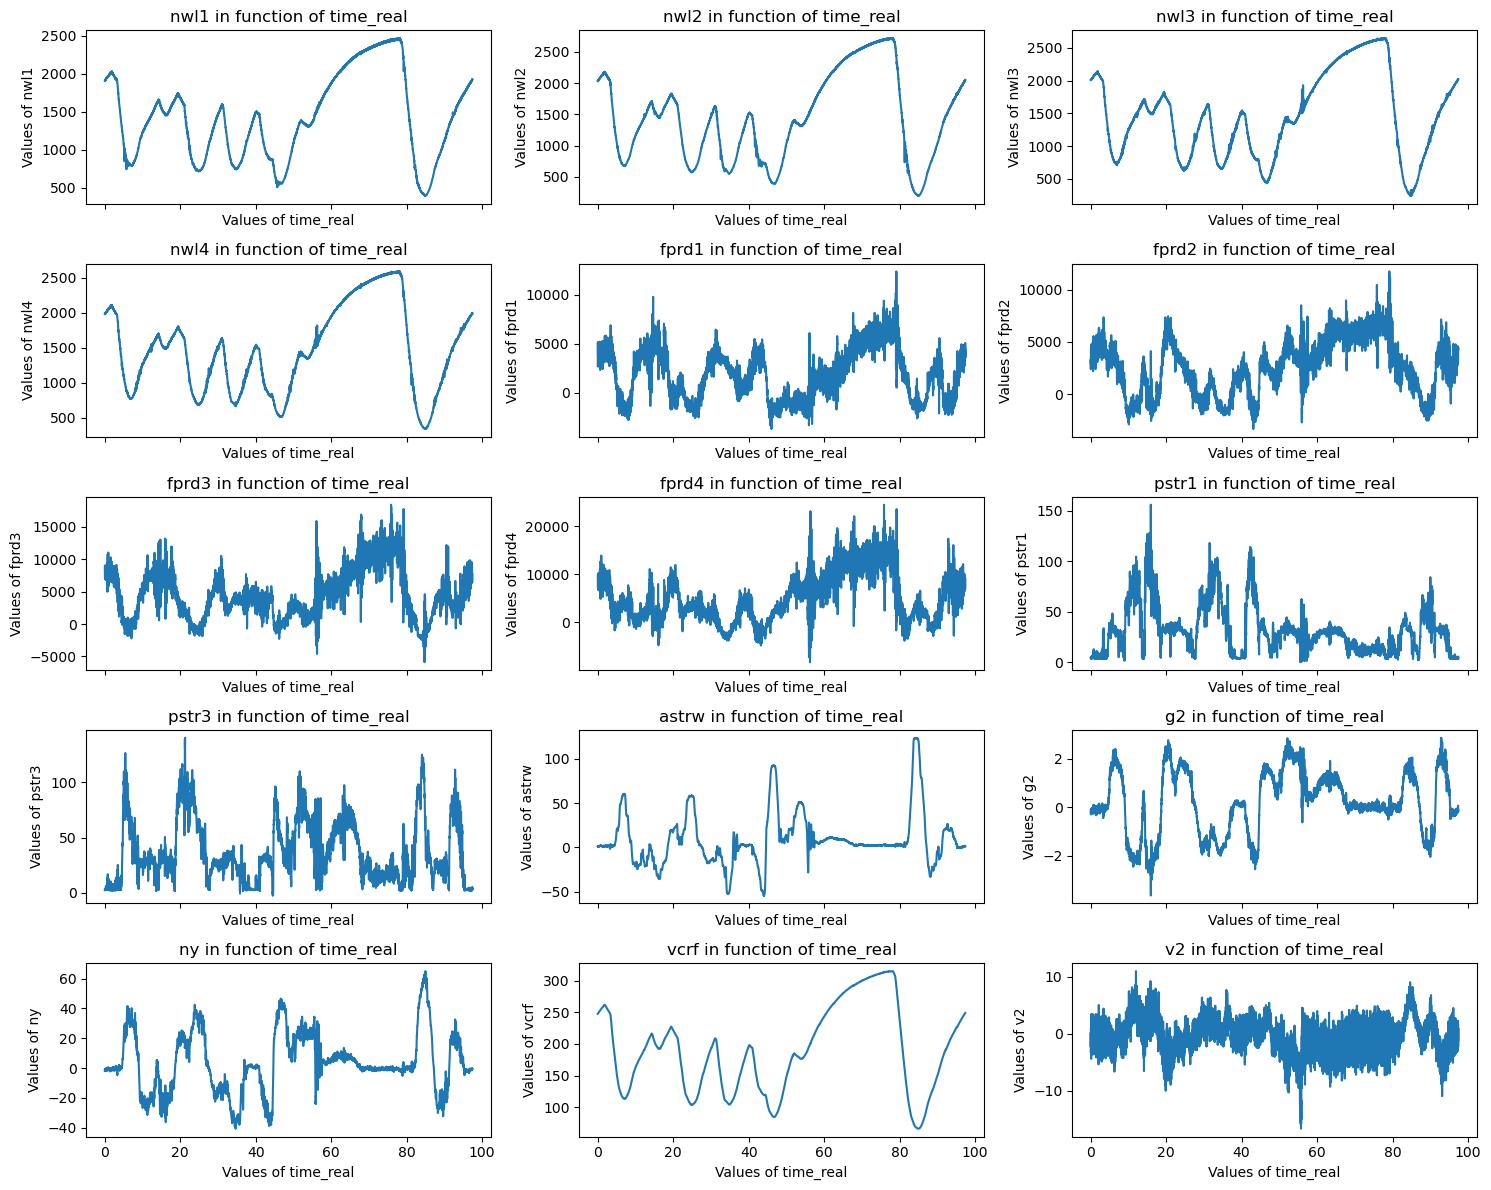

In [13]:
cols = list(df.columns[1:-1])
nrows, ncols = 5, 3
fig, axes = plt.subplots(nrows, ncols, figsize=(15, 12), sharex=True)
axes = axes.flatten()
for ax, col in zip(axes, cols[:nrows * ncols]):
    visualisation.plot(df, 'time_real', col, ax=ax)
for ax in axes[len(cols):]:
    ax.set_visible(False)
plt.tight_layout()
plt.show()

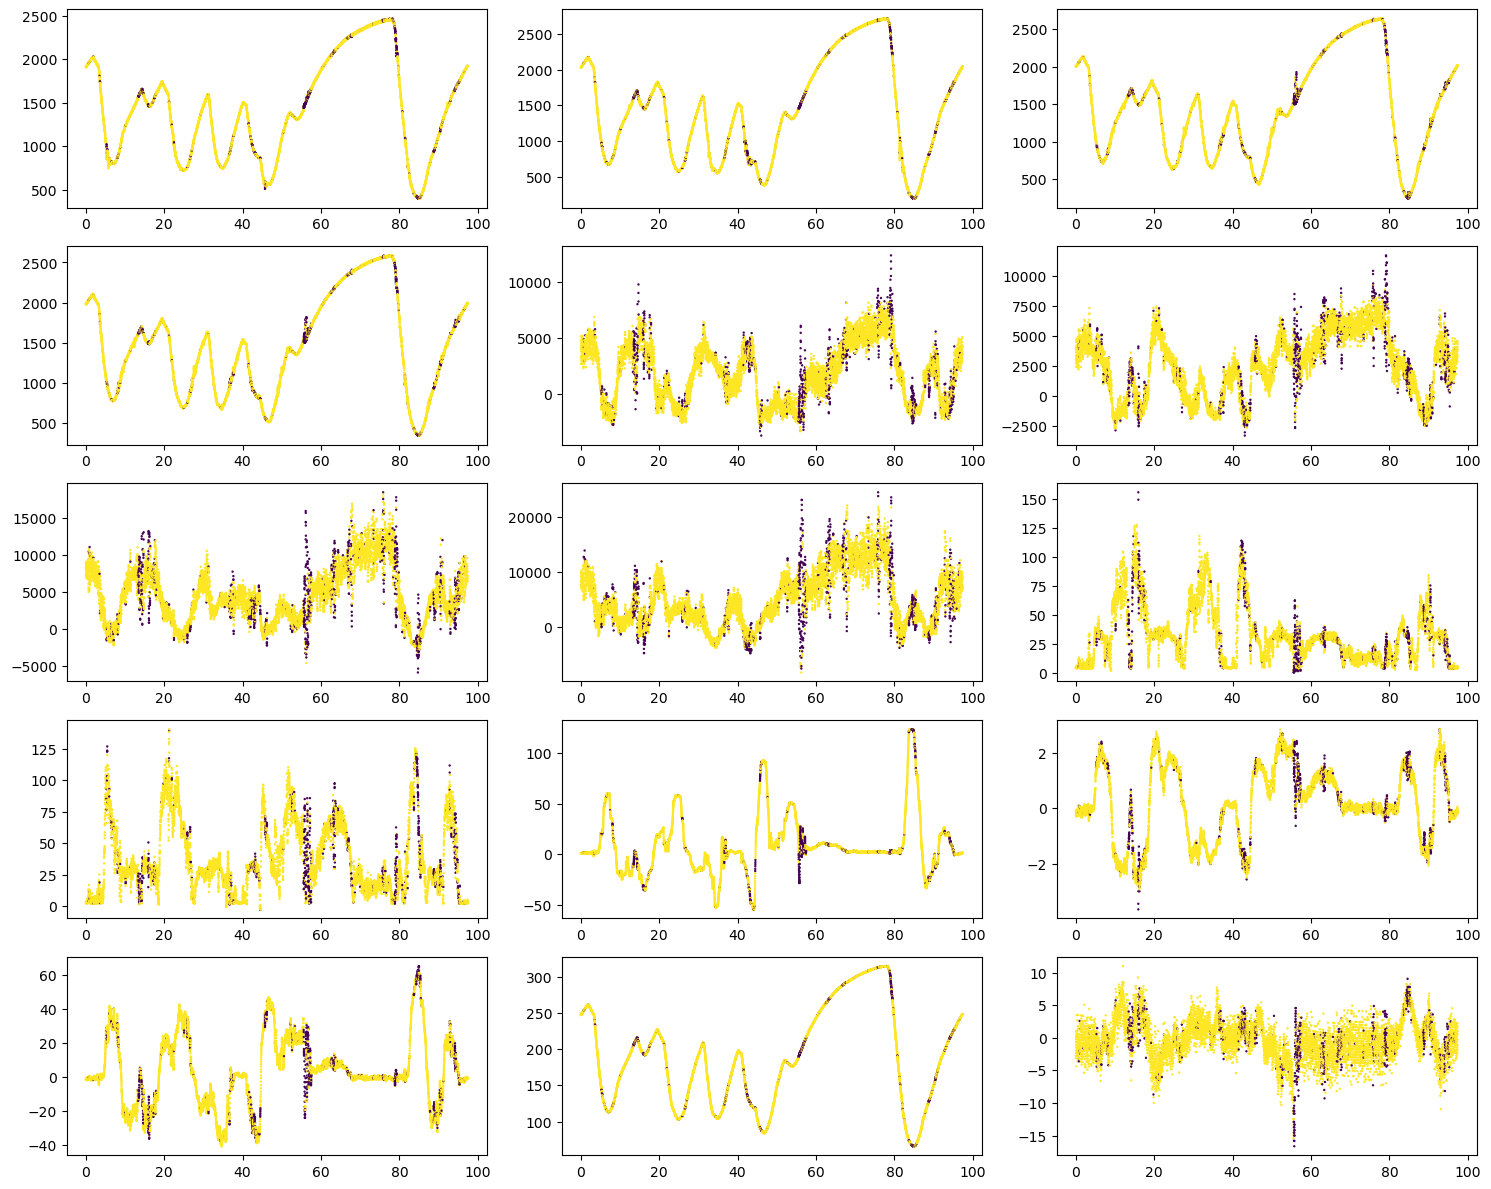

In [14]:
from sklearn.neighbors import LocalOutlierFactor

clf = LocalOutlierFactor(n_neighbors=20, contamination=0.1,n_jobs = -1)
y_pred = clf.fit_predict(df[cols].values)
cols = list(df.columns[1:-1])
nrows, ncols = 5, 3
fig, axes = plt.subplots(nrows, ncols, figsize=(15, 12), sharex=False)
axes = axes.flatten()
for ax, col in zip(axes, cols[:nrows * ncols]):
    ax.scatter(df["time_real"], df[col], s = 0.5, c = y_pred)
for ax in axes[len(cols):]:
    ax.set_visible(False)
plt.tight_layout()
plt.show()

In [15]:
def replace_outliers_moving_average(df, cols, outlier_mask, window=20):
    """
    Replace LOF outliers using moving average interpolation.

    Parameters
    ----------
    df : pandas DataFrame
    cols : columns to clean
    outlier_mask : boolean array (True = outlier)
    window : moving average window size

    Returns
    -------
    df_clean : cleaned dataframe
    """

    df_clean = df.copy()

    for col in cols:

        # compute rolling mean
        rolling_mean = df_clean[col].rolling(window=window, center=True, min_periods=1).mean()

        # replace outliers
        df_clean.loc[outlier_mask, col] = rolling_mean[outlier_mask]

    return df_clean

(array([ 974.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,
        8766.]),
 array([-1. , -0.8, -0.6, -0.4, -0.2,  0. ,  0.2,  0.4,  0.6,  0.8,  1. ]),
 <BarContainer object of 10 artists>)

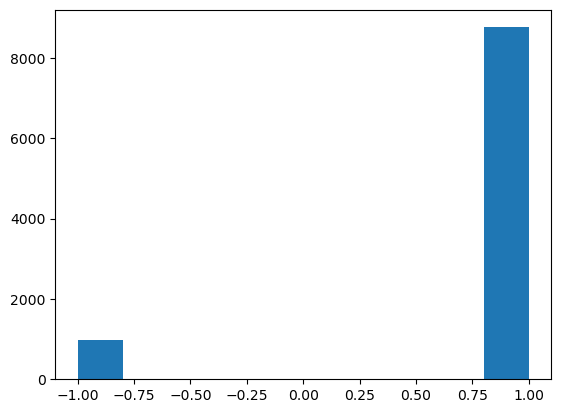

In [16]:
plt.hist(y_pred )

In [17]:
df = replace_outliers_moving_average(df, cols, y_pred == -1)

## Train data and test data

In [18]:
import random

# shuffle sessions
random.seed(423)
sessions = session_clean.copy()
random.shuffle(sessions)

# choose train ratio
train_ratio = 2/3
n_train = int(len(sessions) * train_ratio)

session_train = sessions[:n_train]
session_test = sessions[n_train:]

print(len(session_train), len(session_test))

20 10


## Dataset for PCA

In [30]:
# Prepare dataset for pca training : preprocessing, LOF, imputation and concatenate to a universal dataset

temp_list = []

for s in session_train:
    df = data_dict[s].copy()
    df = preprocessing.clean_dataframe(df)
    if df.shape[0] != 0 :
        clf = LocalOutlierFactor(n_neighbors=20, contamination=0.1,n_jobs = -1)
        y_pred = clf.fit_predict(df[cols].values)
        df = replace_outliers_moving_average(df, cols, y_pred == -1)
        temp_list.append(df)

df_train = pd.concat(temp_list, ignore_index=True)
df_train.head()

,datetime,nwl1,nwl2,nwl3,nwl4,fprd1,fprd2,fprd3,fprd4,pstr1,pstr3,astrw,g2,ny,vcrf,v2,time_real
0,2024-05-02 17:41:56.487,1943.53,2057.32,2043.60,2007.43,3553.33,3147.32,7068.07,7786.28,4.15602,2.35113,-0.302534,-0.168563,-1.020840,251.933,-2.233810,0.00
1,2024-05-02 17:41:56.497,1949.23,2059.68,2040.32,2015.74,3320.34,2825.08,7934.02,7241.65,4.04157,2.23198,-0.237875,-0.109164,-1.292760,252.022,1.096520,0.01
2,2024-05-02 17:41:56.507,1943.53,2066.76,2042.51,2017.82,3328.46,3374.52,8200.22,8578.05,4.18723,2.04783,-0.326781,-0.121044,-1.360730,252.110,0.688087,0.02
3,2024-05-02 17:41:56.517,1944.48,2058.50,2047.97,2010.55,3509.29,3914.68,7446.00,8026.56,4.24966,2.06949,-0.213628,-0.168563,-1.156800,252.199,-0.537226,0.03
4,2024-05-02 17:41:56.527,1951.13,2062.04,2043.60,2018.86,3562.61,3499.70,7748.34,6747.36,3.94793,2.22115,-0.278287,-0.121044,-0.941533,252.287,5.306570,0.04


In [ ]:
# Train PCA of standardized data

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
pca = PCA()
respca = pca.fit_transform(scaler.fit_transform(df_train[cols])) 

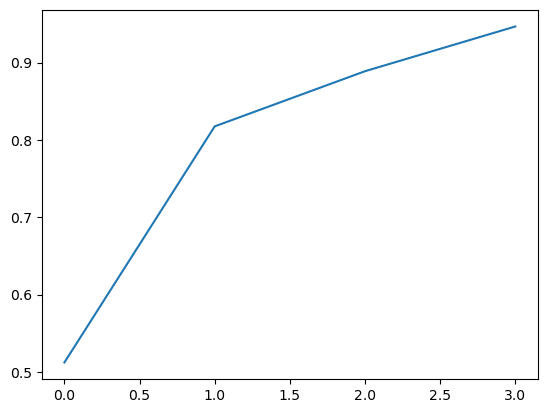

In [ ]:
# Explained variance

plt.plot(np.cumsum(pca.explained_variance_ratio_[:4]))
plt.show()

## Dataset for DPCA

In [24]:
# Function to create lag-augmented matrix

def dynamic_augmentation(X, s):
    """
    Build dynamic augmented matrix:
    [x(t), x(t-1), ..., x(t-s)]
    
    Parameters
    ----------
    X : ndarray of shape (n_samples, m_features)
        Original time series matrix. Row t = x(t).
    s : int
        Lag time.
    
    Returns
    -------
    Xs : ndarray of shape (n_samples - s, m_features * (s + 1))
    """
    X = np.asarray(X)
    n, m = X.shape

    if s < 0:
        raise ValueError("s must be >= 0")
    if s >= n:
        raise ValueError("s must be smaller than number of samples")

    blocks = []
    for lag in range(s + 1):
        blocks.append(X[s - lag : n - lag, :])

    Xs = np.hstack(blocks)
    return Xs

def inverse_dynamic_augmentation(Xs, s, m):
    """
    Reconstruct original time series X from augmented matrix Xs.

    Parameters
    ----------
    Xs : ndarray (n-s, m*(s+1))
        Augmented matrix
    s : int
        Lag used in augmentation
    m : int
        Number of original features

    Returns
    -------
    X : ndarray (n, m)
        Reconstructed original matrix
    """

    n_minus_s = Xs.shape[0]
    n = n_minus_s + s

    X = np.zeros((n, m))
    counts = np.zeros(n)

    for lag in range(s + 1):
        block = Xs[:, lag*m:(lag+1)*m]
        start = s - lag
        end = n - lag

        X[start:end] += block
        counts[start:end] += 1

    X /= counts[:, None]

    return X

In [ ]:
# Prepare dataset for DPCA. The standardization is done before the dynamic augmentation process, with the same scaler as PCA
# The session_index is used to detect the session to which each point belongs

temp_list = []
session_index = []
i = 0
lag = 8
scaler = StandardScaler()
scaler.fit(df_train[cols])
for s in session_train:
    df = data_dict[s].copy()
    df = preprocessing.clean_dataframe(df)
    if df.shape[0] != 0 :
        clf = LocalOutlierFactor(n_neighbors=20, contamination=0.1,n_jobs = -1)
        y_pred = clf.fit_predict(df[cols].values)
        df = replace_outliers_moving_average(df, cols, y_pred == -1)
        df = scaler.transform(df[cols])
        df = dynamic_augmentation(df, s=lag)
        temp_list.append(pd.DataFrame(df))
        session_index.append(np.ones(df.shape[0])*i)
        i = i+1

df_train_dy = pd.concat(temp_list, ignore_index=True)
df_train_dy.head()

,0,1,2,3,4,5,6,7,8,9,...,125,126,127,128,129,130,131,132,133,134
0,0.902615,0.906215,0.897122,0.910858,0.722145,0.466567,0.676921,0.610624,-1.145946,-1.194963,...,0.097309,0.654760,0.564617,-1.138571,-1.190940,-0.282630,-0.275487,-0.239501,0.886925,-0.701942
1,0.904315,0.892463,0.909142,0.895356,0.596164,0.287215,0.596253,0.488704,-1.145078,-1.199718,...,-0.020008,0.888334,0.455118,-1.143343,-1.194963,-0.280264,-0.231079,-0.253040,0.888233,0.314863
2,0.909415,0.899332,0.900547,0.900523,0.513464,0.039917,0.961024,0.516308,-1.144210,-1.196426,...,0.180026,0.960136,0.723804,-1.137269,-1.201181,-0.283518,-0.239960,-0.256425,0.889526,0.190162
3,0.904315,0.909649,0.903988,0.907413,0.447041,0.043715,0.912709,0.832384,-1.145946,-1.193134,...,0.376682,0.756700,0.612926,-1.134666,-1.200450,-0.279377,-0.275487,-0.246271,0.890834,-0.183947
4,0.909415,0.897614,0.910854,0.895356,0.480467,0.081276,0.568775,0.511708,-1.149850,-1.199718,...,0.225600,0.838250,0.355740,-1.147247,-1.195329,-0.281743,-0.239960,-0.235552,0.892127,1.600261


In [31]:
dpca = PCA(n_components=3)
resdpca = dpca.fit_transform(df_train_dy)

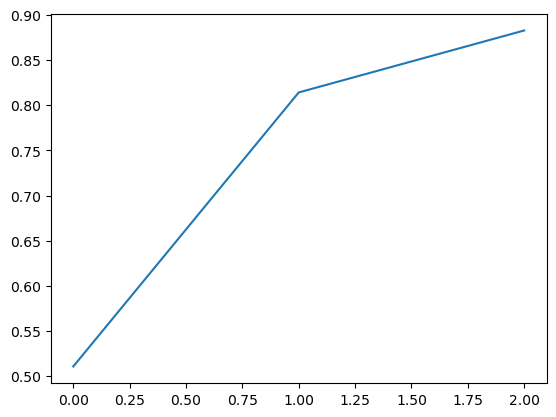

In [32]:
plt.plot(np.cumsum(dpca.explained_variance_ratio_))

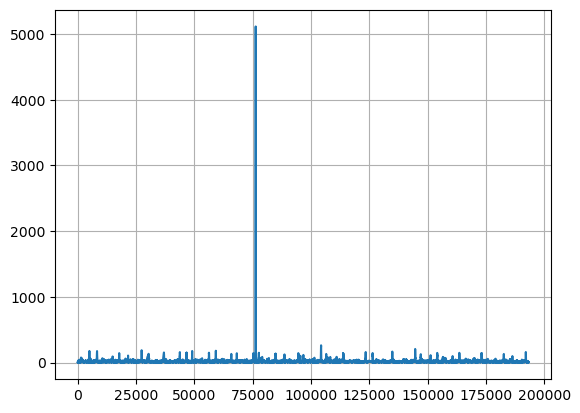

In [34]:
# Visualize the SPE

df_train_dy_inv = dpca.inverse_transform(resdpca)
resid_dpca = df_train_dy - df_train_dy_inv
SPEd = np.sum(resid_dpca**2, axis = 1)
error_dy = resid_dpca**2
plt.plot(SPEd)
plt.grid()
plt.show()

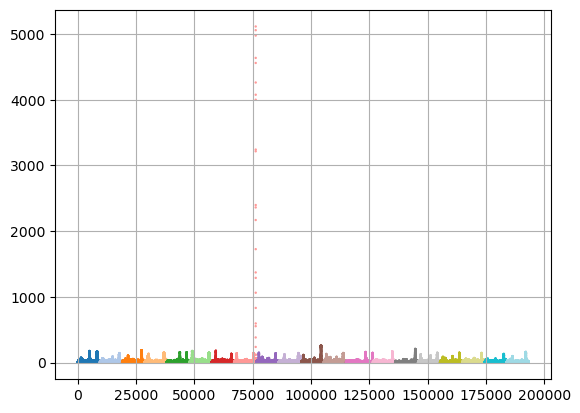

In [35]:
# SPE colored by sessions

list_index = np.concatenate(session_index)
sc = plt.scatter(range(len(SPEd)),SPEd,s=0.5, c=list_index,cmap="tab20")
plt.grid()
plt.show()

In [37]:
# Detect the session having the unusually high SPE

np.unique(list_index[SPEd>500])

array([7.])

**Comments:** session 8 in the session_train might have anomalies. To have a reliable PCA/DPCA space, we need to remove the outlier.

In [38]:
# Print the name of the anomalous session.

key = session_train[7]
key

'd:\\GMM 4\\Reading seminar\\data_download\\gdrive_tar_data\\extracted\\fetching_data_examples_for_PIR-ARAG24\\T24S12-04_E-AL3651.csv'

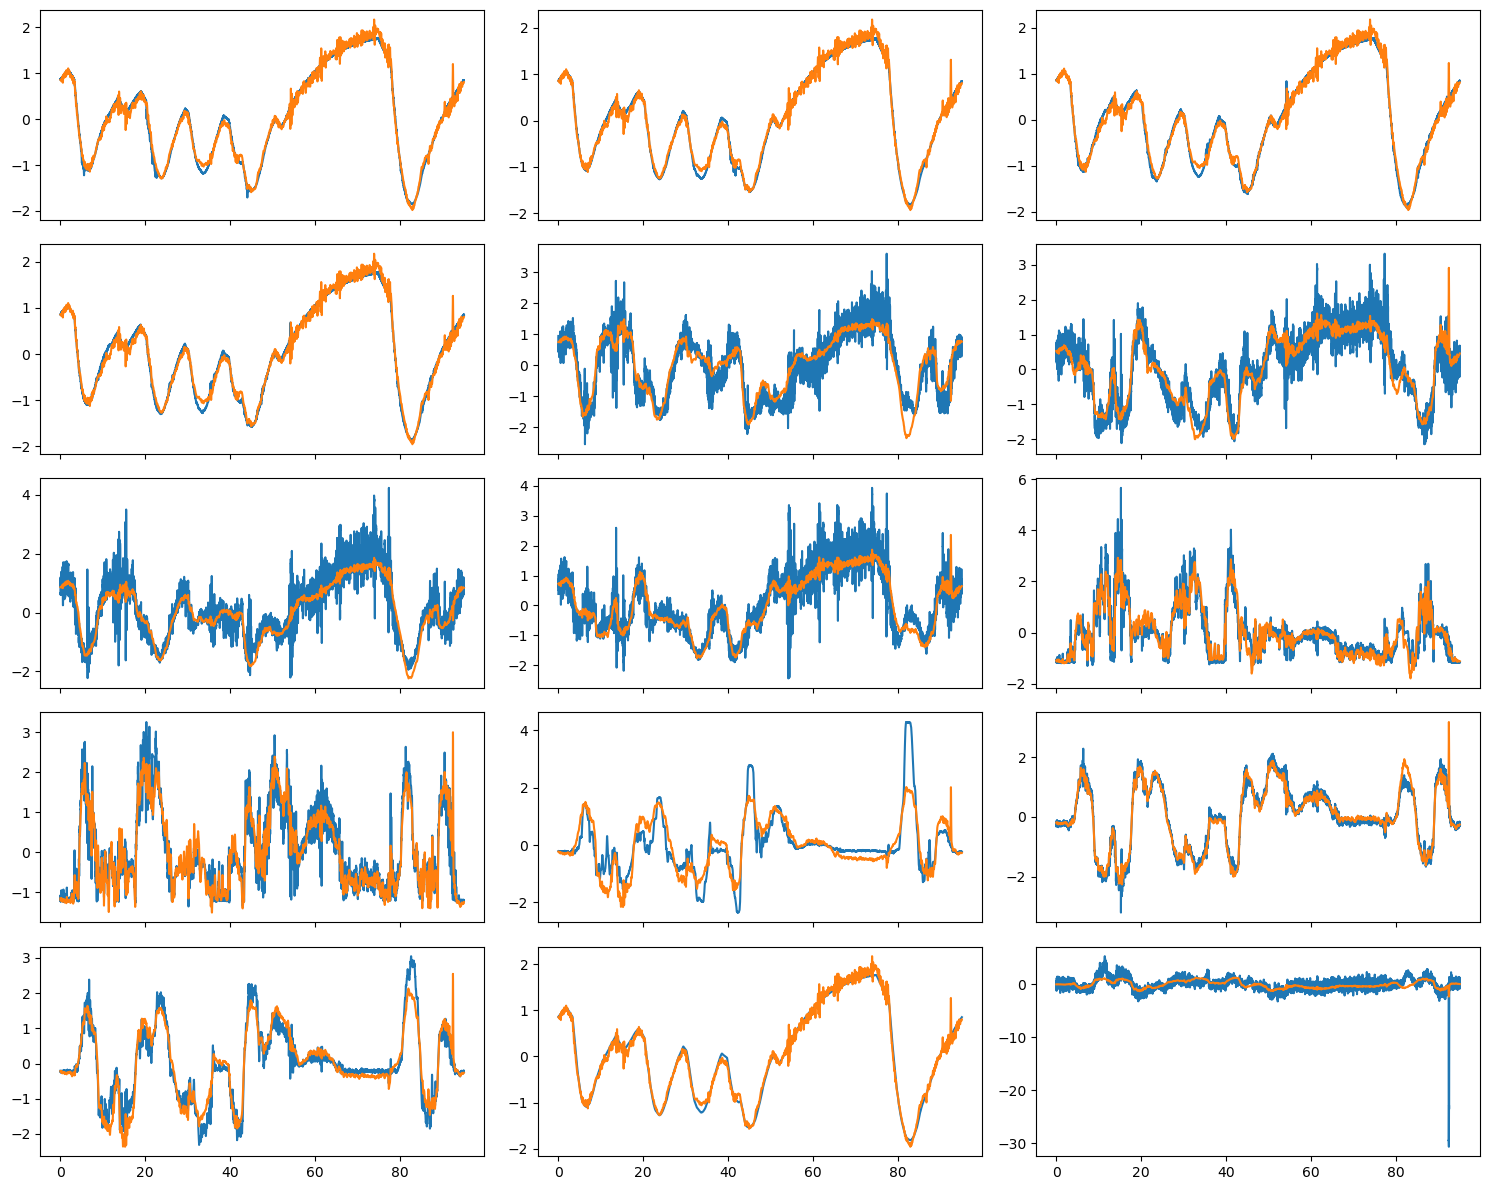

In [39]:
# Plot the inverse transform of the 8th session

df_err = preprocessing.clean_dataframe(data_dict[key].copy())
res_err = dpca.transform(dynamic_augmentation(scaler.transform(df_err[cols]),s=lag))
inv = inverse_dynamic_augmentation(dpca.inverse_transform(res_err),s=lag,m=len(cols))

df_err_center = scaler.transform(df_err[cols])
nrows, ncols = 5, 3
fig, axes = plt.subplots(nrows, ncols, figsize=(15, 12), sharex=True)
axes = axes.flatten()
for ax, col in zip(axes, cols[:nrows * ncols]):
    ax.plot(df_err["time_real"].values, df_err_center[:,cols.index(col)])
    ax.plot(df_err["time_real"].values, inv[:,cols.index(col)])
for ax in axes[len(cols):]:
    ax.set_visible(False)
plt.tight_layout()
plt.show()

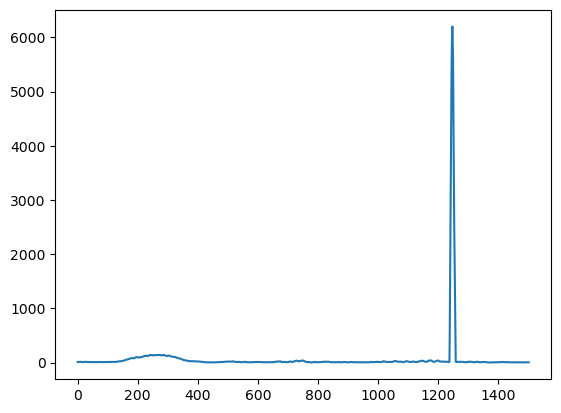

In [41]:
# Plot the SPE of the 8th session

df_err_center = scaler.transform(df_err[cols])
error8 = (dynamic_augmentation(df_err_center,s=lag) - dpca.inverse_transform(res_err))**2
plt.plot(np.sum(error8,axis=1)[8000:])
plt.show() 

**Comment:** Since the error is high at the end of the session, we can remove this part and keep the rest.

## Retrain the pca and dpca on clean data

### PCA

In [43]:
temp_list = []

for s in session_train:
    df = data_dict[s].copy()
    df = preprocessing.clean_dataframe(df)
    if df.shape[0] != 0 :
        clf = LocalOutlierFactor(n_neighbors=20, contamination=0.1,n_jobs = -1)
        y_pred = clf.fit_predict(df[cols].values)
        df = replace_outliers_moving_average(df, cols, y_pred == -1)
        if s == session_train[7]:
            df = df.iloc[:9200,:]
        temp_list.append(df)

df_train = pd.concat(temp_list, ignore_index=True)
scaler = StandardScaler()
pca = PCA(n_components=3)
respca = pca.fit_transform(scaler.fit_transform(df_train[cols]))

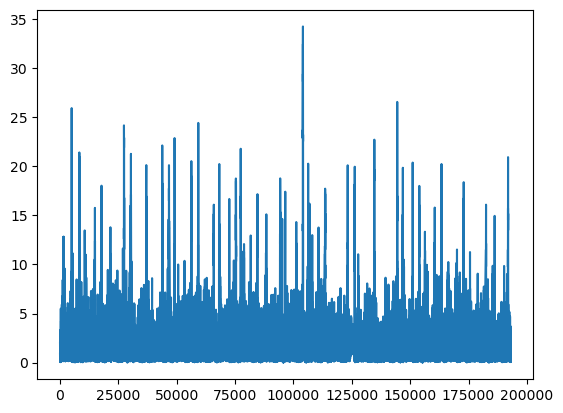

In [44]:
# SPE of PCA

df_train_inv = pca.inverse_transform(respca)
SPEpca = np.sum((scaler.transform(df_train[cols]) - df_train_inv)**2,axis=1)
plt.plot(SPEpca)
plt.show()

In [45]:
# Detect the threshold for anomalies

from scipy.stats import chi2

a = np.mean(SPEpca)
b = np.var(SPEpca)
alpha = 0.01
nu = 2 * a**2 / b
seuil = (b / (2*a)) * chi2.ppf(1 - alpha, nu)
seuil

np.float64(10.05350444957435)

### DPCA

In [46]:
temp_list = []
session_index = []
i = 0
lag = 8
scaler = StandardScaler()
scaler.fit(df_train[cols])
for s in session_train:
    df = data_dict[s].copy()
    df = preprocessing.clean_dataframe(df)
    if df.shape[0] != 0 :
        clf = LocalOutlierFactor(n_neighbors=20, contamination=0.1,n_jobs = -1)
        y_pred = clf.fit_predict(df[cols].values)
        df = replace_outliers_moving_average(df, cols, y_pred == -1)
        if i == 7:
            df = df.iloc[:9200,:]
        df = scaler.transform(df[cols])
        df = dynamic_augmentation(df, s=lag)
        temp_list.append(pd.DataFrame(df))
        session_index.append(np.ones(df.shape[0])*i)
        i = i+1

df_train_dy = pd.concat(temp_list, ignore_index=True)

In [47]:
dpca = PCA(n_components=3)
resdpca = dpca.fit_transform(df_train_dy)
df_train_dy_inv = dpca.inverse_transform(resdpca)
resid_dpca = df_train_dy - df_train_dy_inv
error_dy = resid_dpca**2
SPEd = np.sum(error_dy, axis = 1)

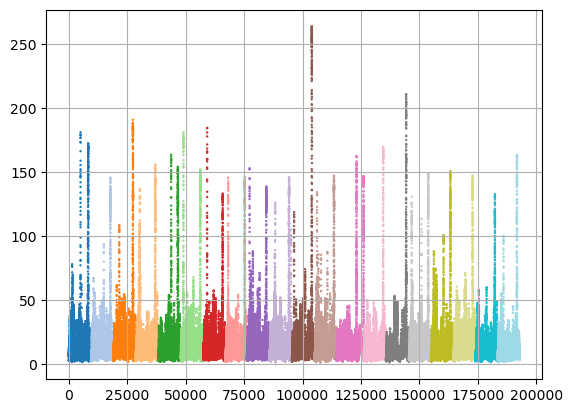

In [48]:
list_index = np.concatenate(session_index)
sc = plt.scatter(range(len(SPEd)),SPEd,s=0.5, c=list_index,cmap="tab20")
plt.grid()
plt.show()

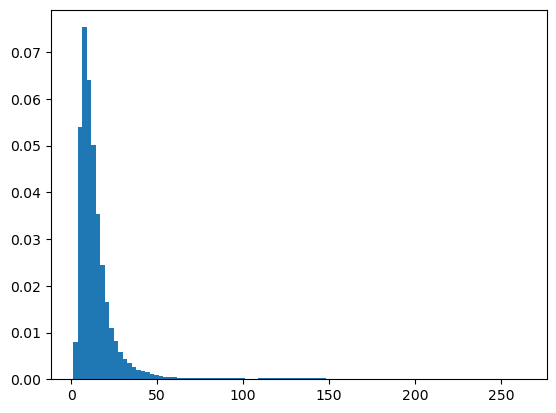

In [49]:
# Distribution of the SPE DPCA

plt.hist(SPEd, bins=100,density=True)
plt.show()

In [50]:
# Calculate the threshold of SPE of DPCA

from scipy.stats import chi2

a = np.mean(SPEd)
b = np.var(SPEd)
alpha = 0.01
nu = 2 * a**2 / b
seuilD = (b / (2*a)) * chi2.ppf(1 - alpha, nu)
seuilD

np.float64(84.60644068933212)

# Analysis on test data

## PCA

In [56]:
# Projection on PCA space of the 8th session_test

df = data_dict[session_test[8]].copy()
df = preprocessing.clean_dataframe(df)
df_center = scaler.transform(df[cols])
respca = pca.transform(df_center)

In [57]:
# Reconstructed data

resinv = respca.copy()
resinv[:,4:] = 0
dfinv = pca.inverse_transform(resinv)

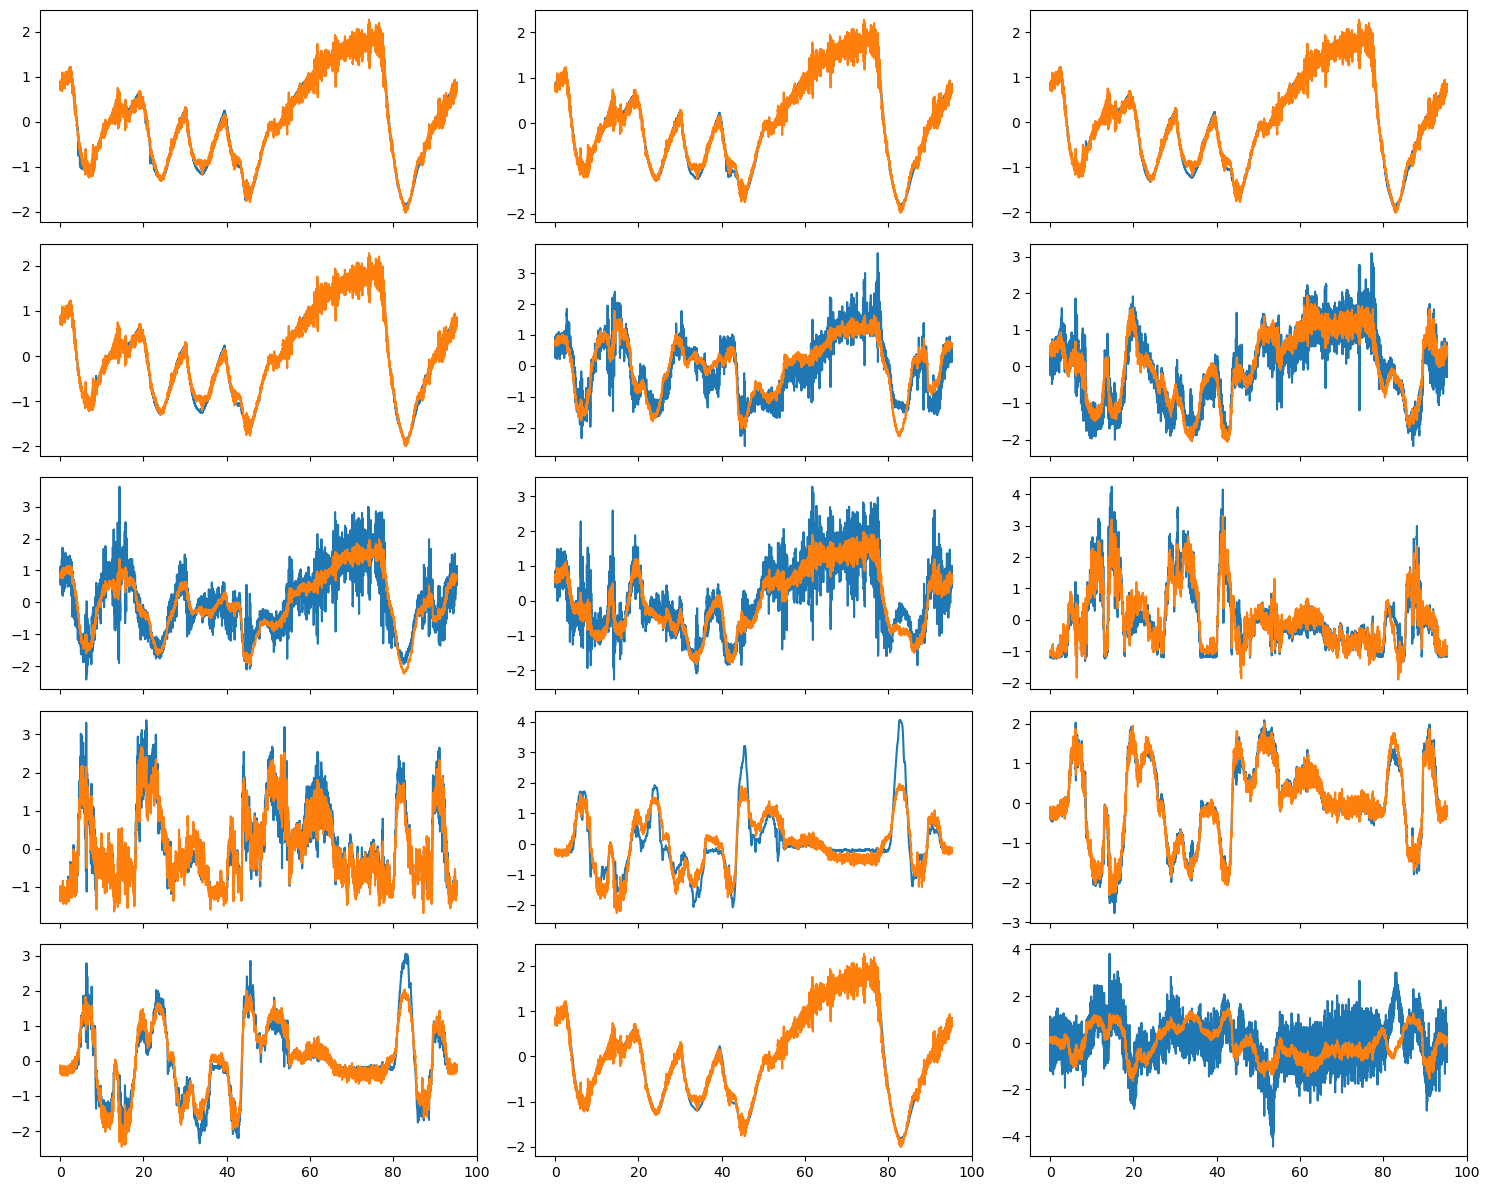

In [58]:
# Visualize reconstructed data

nrows, ncols = 5, 3
fig, axes = plt.subplots(nrows, ncols, figsize=(15, 12), sharex=True)
axes = axes.flatten()
for ax, col in zip(axes, cols[:nrows * ncols]):
    ax.plot(df["time_real"].values, df_center[:,cols.index(col)])
    ax.plot(df["time_real"].values, dfinv[:,cols.index(col)])
for ax in axes[len(cols):]:
    ax.set_visible(False)
plt.tight_layout()
plt.show()

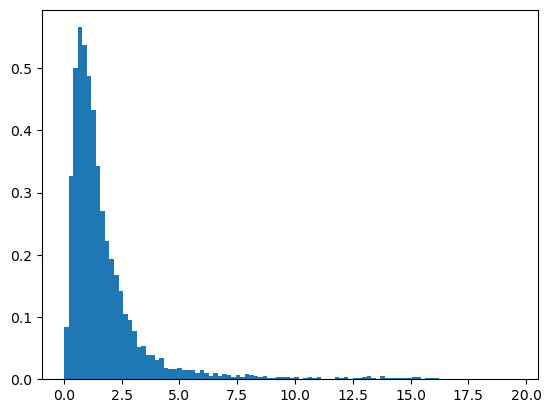

In [59]:
# Distribution of SPE

SPEref = np.sum((df_center - dfinv)**2, axis=1)
plt.hist(SPEref, density=True, bins = 100)
plt.show()

In [60]:
# Number of anomalies

np.sum(SPEref > seuil)

np.int64(143)

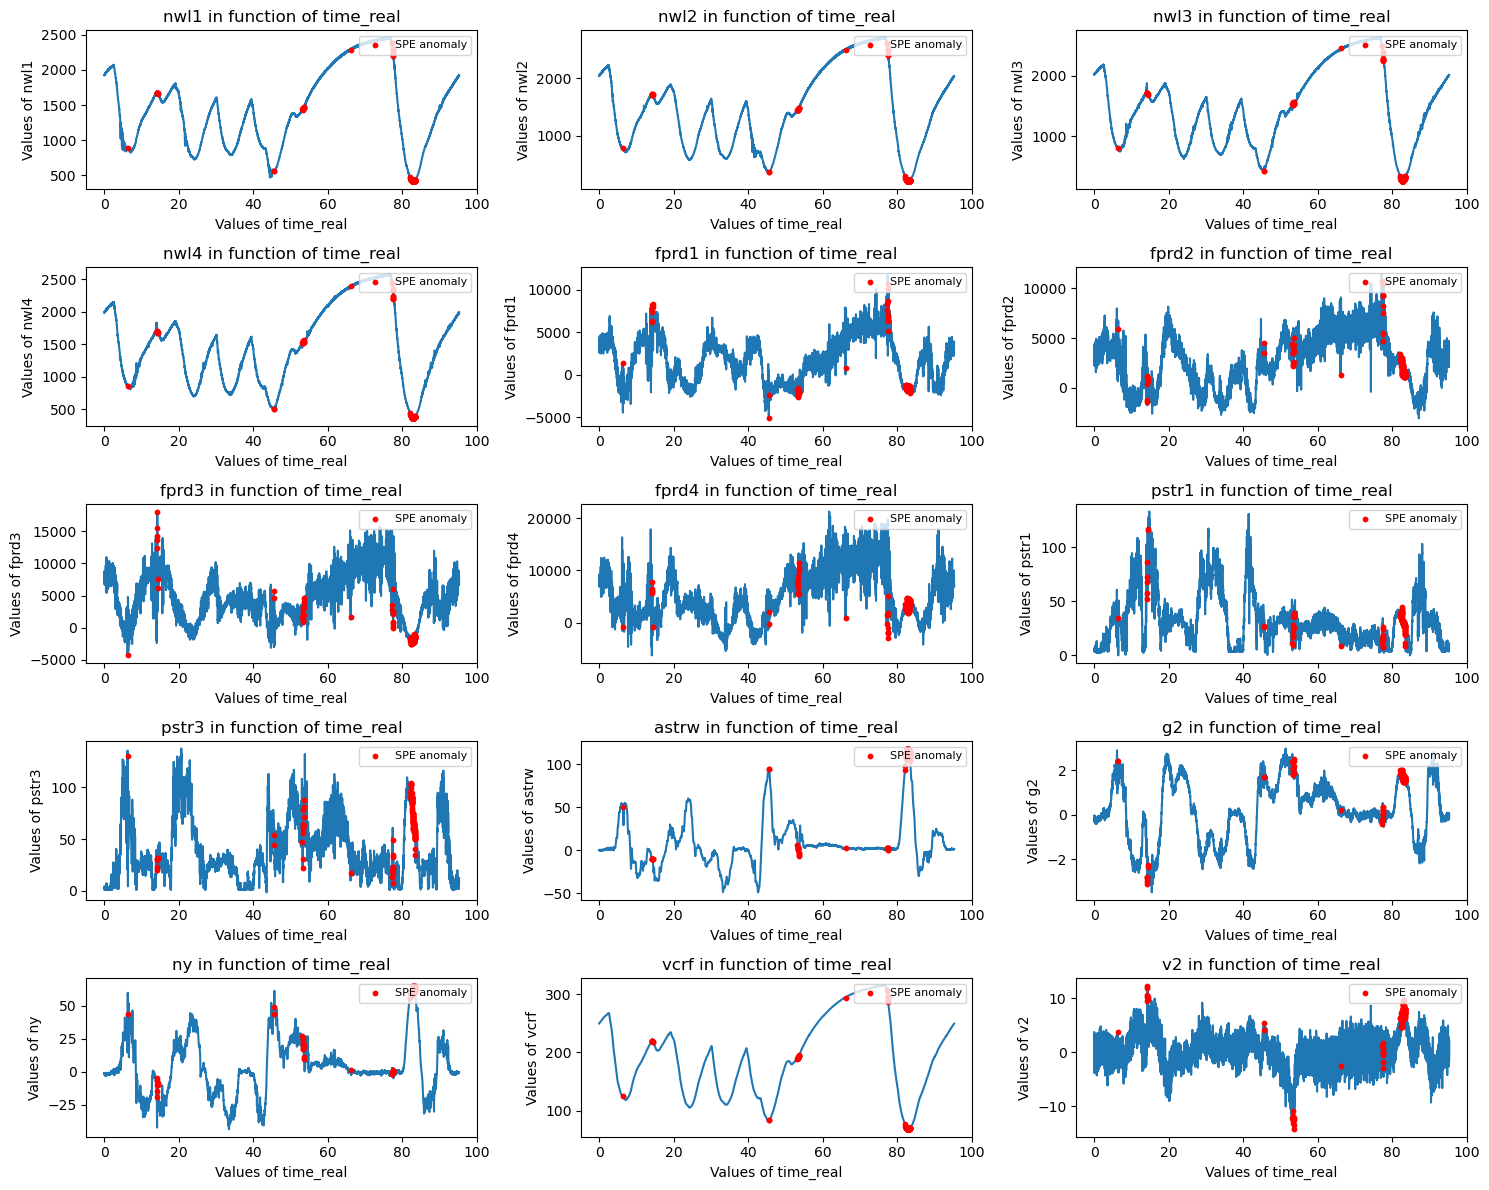

In [63]:
# Visualize anomalies

anomaly_mask = SPEref > seuil
anomaly_times = df.loc[anomaly_mask, 'time_real']

nrows, ncols = 5, 3
fig, axes = plt.subplots(nrows, ncols, figsize=(15, 12), sharex=False)
axes = axes.flatten()

for ax, col in zip(axes, cols[:nrows * ncols]):

    # original signal plot
    visualisation.plot(df, 'time_real', col, ax=ax)

    # overlay anomaly points
    ax.scatter(
        anomaly_times,
        df.loc[anomaly_mask, col],
        color='red',
        s=10,
        label='SPE anomaly',
        zorder=3
    )

    ax.legend(loc="upper right", fontsize=8)

# hide unused axes
for ax in axes[len(cols):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()


<Axes: ylabel='time_real'>

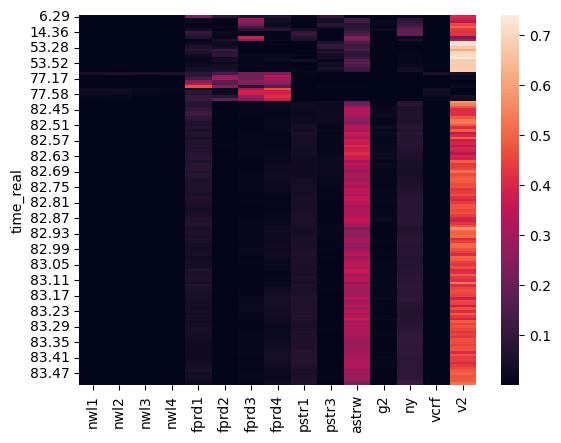

In [ ]:
# Heat map of the error to detect the cause of anomalies

error_ref = (df_center - dfinv)**2
error_ref = error_ref/np.reshape(SPEref,(len(SPEref),1)) #standardize to have the contribution of each sensor to the anomalies
error_ref = pd.DataFrame(error_ref)
error_ref.columns = cols
error_ref.index = df["time_real"]

import seaborn as sns
sns.heatmap(error_ref.loc[anomaly_mask])

**Comments:** The anoamlies are mostly due to fprd, astrw and v2

## Dynamic PCA

In [65]:
# Projection on DPCA space

df_dy = dynamic_augmentation(df_center,lag)
resdy = dpca.transform(df_dy)

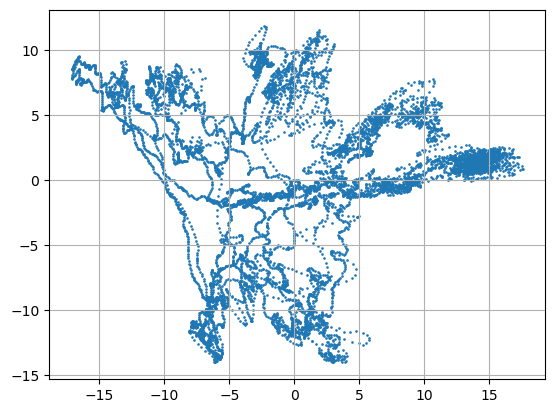

In [66]:
# Visualization of projected data on DPCA space

plt.scatter(resdy[:,0], resdy[:,1], s = 0.8)
plt.grid()
plt.show()

In [67]:
# Inverse transform

df_dy_inv = dpca.inverse_transform(resdy)
df_dy_inv = inverse_dynamic_augmentation(df_dy_inv, lag, len(cols))

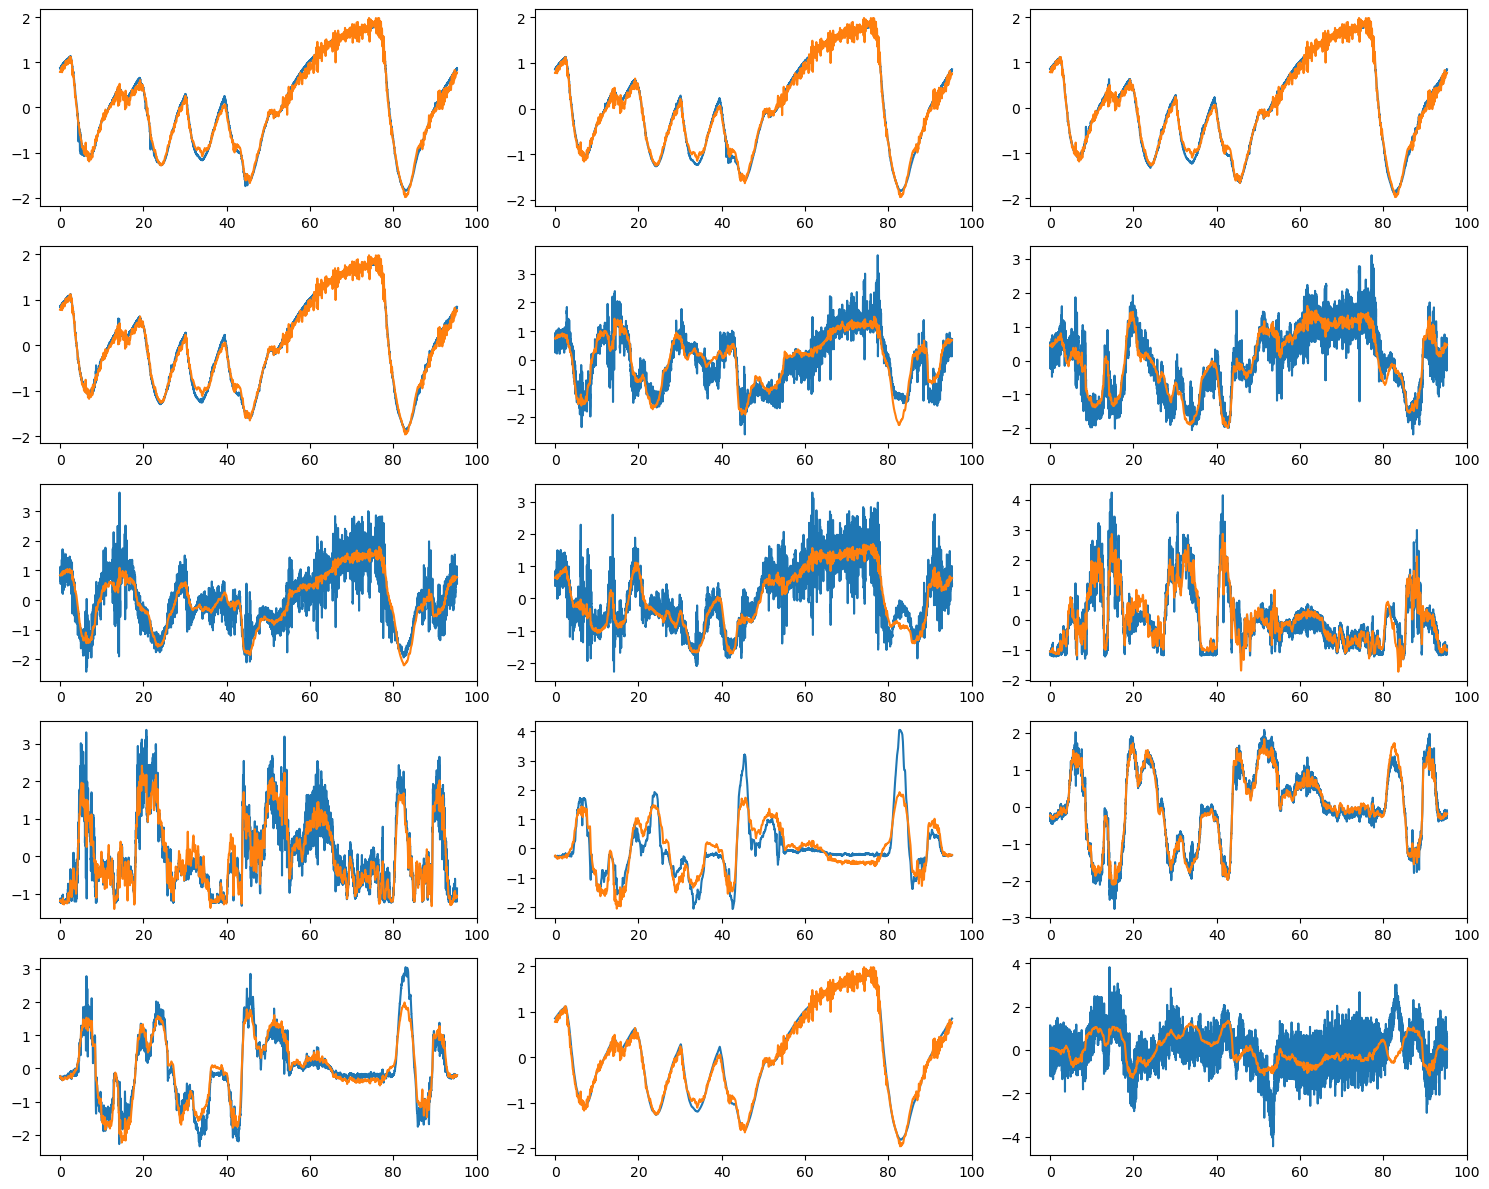

In [80]:
# VIsualize original data vs reconstructed data

nrows, ncols = 5, 3
fig, axes = plt.subplots(nrows, ncols, figsize=(15, 12), sharex=False)
axes = axes.flatten()
for ax, col in zip(axes, cols[:nrows * ncols]):
    ax.plot(df["time_real"].values, df_center[:,cols.index(col)])
    ax.plot(df["time_real"].values, df_dy_inv[:,cols.index(col)])
for ax in axes[len(cols):]:
    ax.set_visible(False)
plt.tight_layout()
plt.show()

**Comments** The reconstructed data of DPCA seems to be smoother than PCA.

In [70]:
SPE = np.sum((df_dy - dpca.inverse_transform(resdy))**2, axis=1)

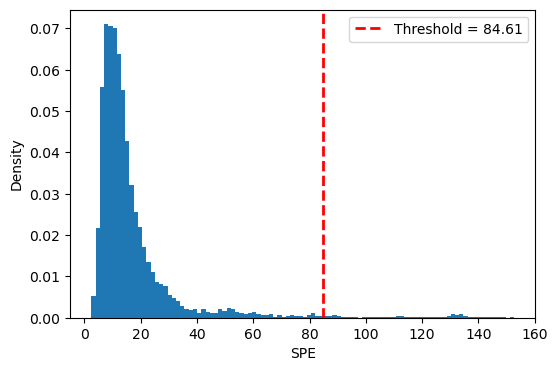

In [72]:
# Visualize the distribution of SPE DPCA with the threshold

plt.figure(figsize=(6,4))
plt.hist(SPE, bins=100, density=True)

# vertical threshold line
plt.axvline(seuilD, color='red', linestyle='--', linewidth=2, label=f'Threshold = {seuilD:.2f}')

plt.xlabel("SPE")
plt.ylabel("Density")
plt.legend()
plt.show()

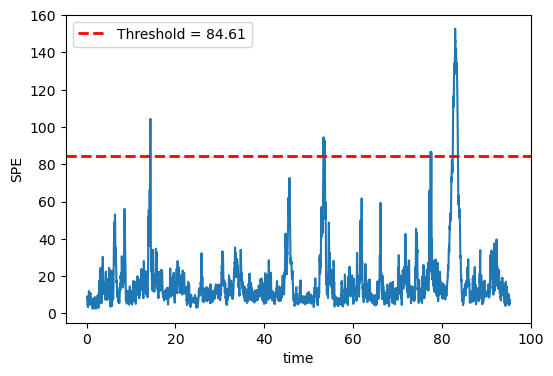

In [73]:
# Visualize SPE DPCA with the threshold

plt.figure(figsize=(6,4))
plt.plot(df["time_real"].values[lag:],SPE)
plt.axhline(seuilD, color='red', linestyle='--', linewidth=2, label=f'Threshold = {seuilD:.2f}')
plt.xlabel("time")
plt.ylabel("SPE")
plt.legend()
plt.show()

In [74]:
# number of anomalies

sum(SPE>seuilD)

np.int64(150)

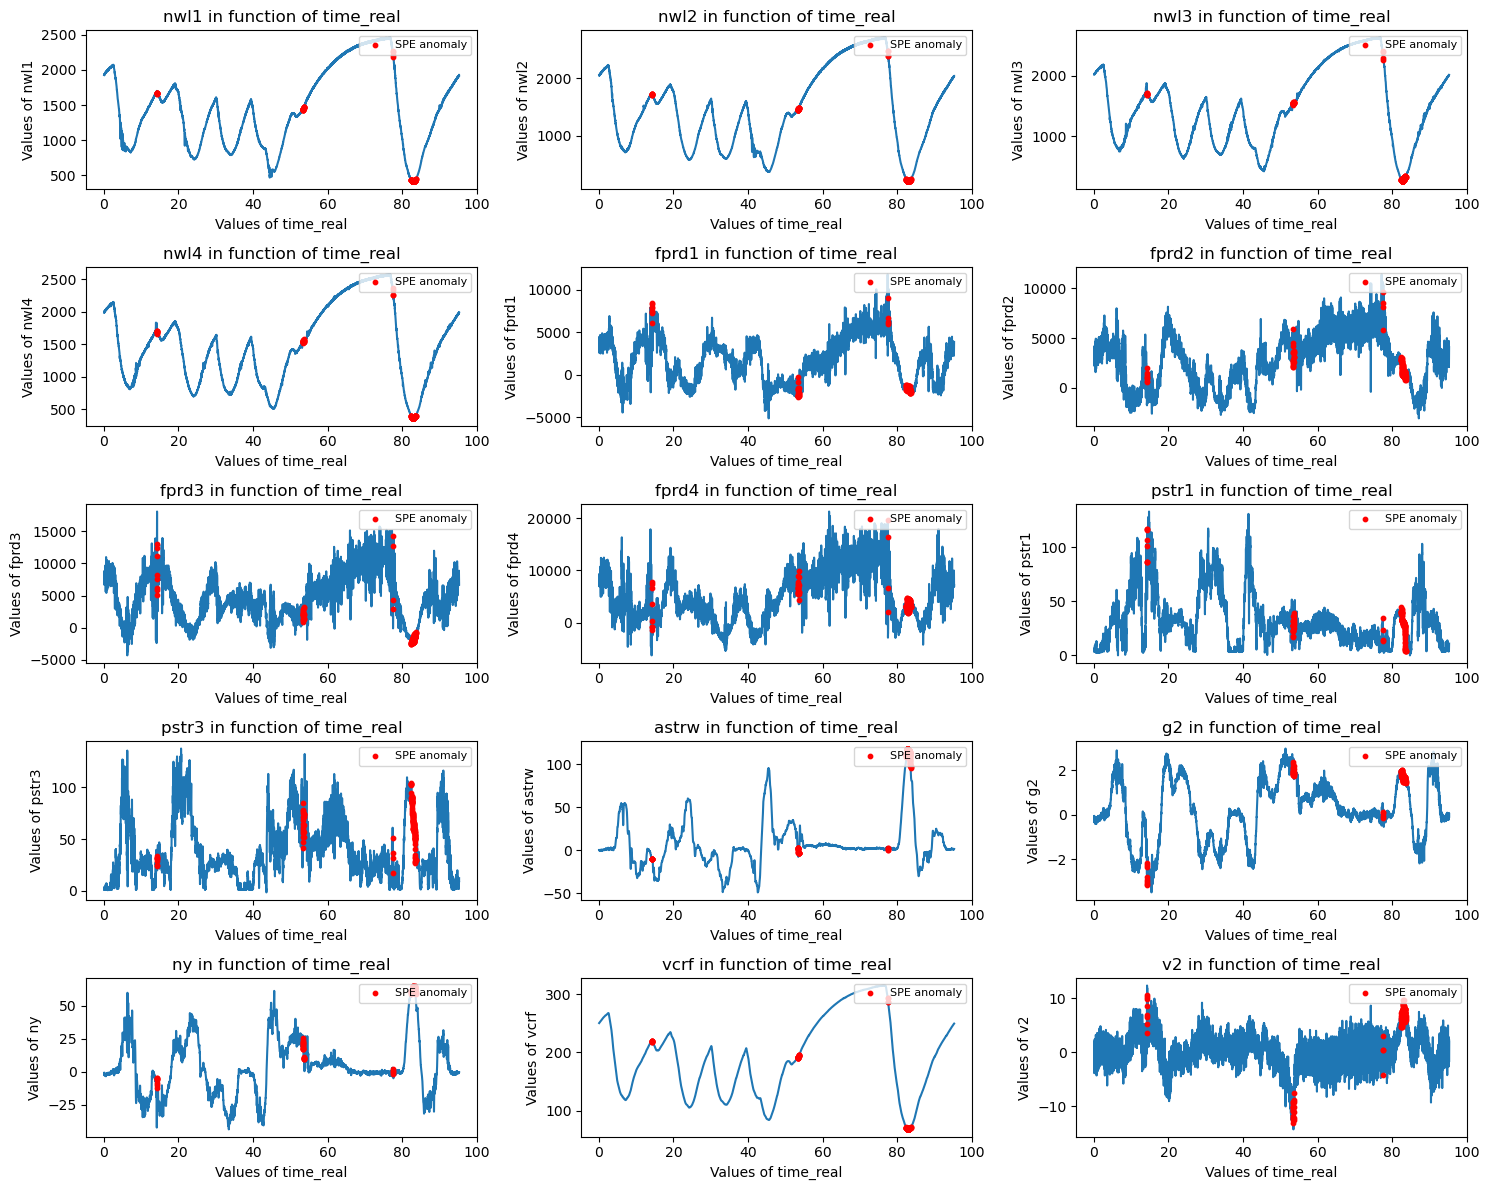

In [79]:
anomaly_mask = SPE > seuilD
dfD= df.iloc[lag:,:]
anomaly_times = dfD.loc[anomaly_mask, 'time_real']

nrows, ncols = 5, 3
fig, axes = plt.subplots(nrows, ncols, figsize=(15, 12), sharex=False)
axes = axes.flatten()

for ax, col in zip(axes, cols[:nrows * ncols]):

    # original signal plot
    visualisation.plot(dfD, 'time_real', col, ax=ax)

    # overlay anomaly points
    ax.scatter(
        anomaly_times,
        dfD.loc[anomaly_mask, col],
        color='red',
        s=10,
        label='SPE anomaly',
        zorder=3
    )

    ax.legend(loc="upper right", fontsize=8)

# hide unused axes
for ax in axes[len(cols):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

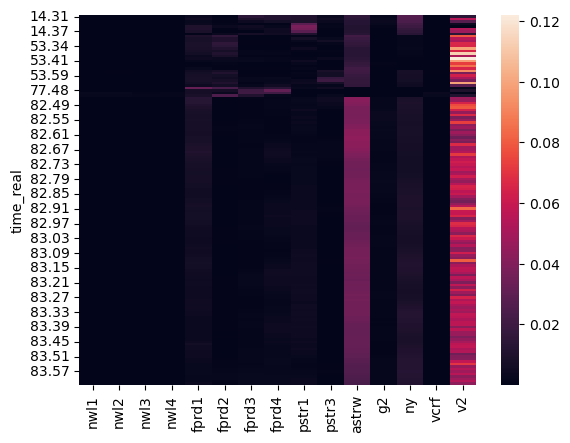

In [78]:
# Visualize the contribution of each sensor to the anomalies

error = (df_dy - dpca.inverse_transform(resdy))**2
error = error/np.reshape(SPE,(len(SPE),1))
error = pd.DataFrame(error).iloc[:,:len(cols)]
error.columns = cols
error.index = dfD["time_real"]
sns.heatmap(error.loc[anomaly_mask])
plt.show()

**Comments** For DPCA, the contribution of fprd and astrw is less signficant, and the v2 is considered as the main source of anomalies. In general the 2 results are quite similar.